Complete the exercises below For **Assignment #5**.

In this exercise, we are building a logistic regression classification model. We'll work with the [Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database).  

Load the `tidymodels` library. 

In [1]:
library('tidymodels')
library('tidyverse')

── Attaching packages ────────────────────────────────────── tidymodels 1.4.1 ──

✔ broom        1.0.9     ✔ recipes      1.3.1
✔ dials        1.4.2     ✔ rsample      1.3.1
✔ dplyr        1.1.4     ✔ tailor       0.1.0
✔ ggplot2      3.5.2     ✔ tidyr        1.3.1
✔ infer        1.0.9     ✔ tune         2.0.0
✔ modeldata    1.5.1     ✔ workflows    1.3.0
✔ parsnip      1.3.3     ✔ workflowsets 1.1.1
✔ purrr        1.1.0     ✔ yardstick    1.3.2

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ purrr::discard() masks scales::discard()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ recipes::step()  masks stats::step()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ readr     2.1.5     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ readr::col_factor() masks scales::col_f

The data is located in your homework directory in the `diabetes.csv` file. Read in the data by running the following cell. We are "splitting" the data into training and testing sets. We will evaluate our model's performance with the test set.

In [2]:
diabetes = readr::read_csv('diabetes.csv', show_col_types = FALSE) |> mutate(Outcome = factor(Outcome))

split = initial_split(diabetes, strata = Outcome)

diabetes_train = training(split)
diabetes_test = testing(split)

Glimpse the `diabetes_train` table.

In [3]:
glimpse(diabetes_train)

tail(diabetes_train)  # just because I want to get an idea for what the data is showing...
head(diabetes_train)


Rows: 576
Columns: 9
$ Pregnancies              <dbl> 1, 5, 10, 4, 3, 8, 1, 13, 5, 3, 6, 10, 4, 3, …
$ Glucose                  <dbl> 89, 116, 115, 110, 126, 99, 97, 145, 109, 88,…
$ BloodPressure            <dbl> 66, 74, 0, 92, 88, 84, 66, 82, 75, 58, 92, 78…
$ SkinThickness            <dbl> 23, 0, 0, 0, 41, 0, 15, 19, 26, 11, 0, 31, 33…
$ Insulin                  <dbl> 94, 0, 0, 0, 235, 0, 140, 110, 0, 54, 0, 0, 1…
$ BMI                      <dbl> 28.1, 25.6, 35.3, 37.6, 39.3, 35.4, 23.2, 22.…
$ DiabetesPedigreeFunction <dbl> 0.167, 0.201, 0.134, 0.191, 0.704, 0.388, 0.4…
$ Age                      <dbl> 21, 30, 29, 30, 27, 50, 22, 57, 60, 22, 28, 4…
$ Outcome                  <fct> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …


Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
6,162,62,0,0,24.3,0.178,50,1
0,181,88,44,510,43.3,0.222,26,1
8,154,78,32,0,32.4,0.443,45,1
0,123,72,0,0,36.3,0.258,52,1
9,170,74,31,0,44.0,0.403,43,1
1,126,60,0,0,30.1,0.349,47,1


Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,89,66,23,94,28.1,0.167,21,0
5,116,74,0,0,25.6,0.201,30,0
10,115,0,0,0,35.3,0.134,29,0
4,110,92,0,0,37.6,0.191,30,0
3,126,88,41,235,39.3,0.704,27,0
8,99,84,0,0,35.4,0.388,50,0


In [4]:
glimpse(diabetes_test)  #just to see what the this looks like to compare with _train

Rows: 192
Columns: 9
$ Pregnancies              <dbl> 1, 8, 10, 0, 1, 7, 10, 7, 5, 3, 11, 1, 7, 1, …
$ Glucose                  <dbl> 85, 183, 139, 118, 103, 196, 125, 147, 117, 1…
$ BloodPressure            <dbl> 66, 64, 80, 84, 30, 90, 70, 76, 92, 76, 76, 5…
$ SkinThickness            <dbl> 29, 0, 0, 47, 38, 0, 26, 0, 0, 36, 0, 0, 0, 1…
$ Insulin                  <dbl> 0, 0, 0, 230, 83, 0, 115, 0, 0, 245, 0, 0, 0,…
$ BMI                      <dbl> 26.6, 23.3, 27.1, 45.8, 43.3, 39.8, 31.1, 39.…
$ DiabetesPedigreeFunction <dbl> 0.351, 0.672, 1.441, 0.551, 0.183, 0.451, 0.2…
$ Age                      <dbl> 31, 32, 57, 31, 33, 41, 41, 43, 38, 28, 35, 2…
$ Outcome                  <fct> 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, …


❓ Which variable is suitable as the "outcome" in a logistic regression model?
## The variable that is suitable as the outcome in this logistic regression model is whether the person has diabetes or not.  This would be reflected in the "Outcome" column as either a '1' or a '0'.   


❓ Navigate to [Kaggle page](https://www.kaggle.com/datasets/mathchi/diabetes-data-set) for this dataset. Find descriptions for the `Glucose` and `BMI` columns. Add these descriptions to the [Markdown table](https://www.markdownguide.org/extended-syntax/#tables) below.

| Column name | Description                                                                         |
| :---------- | :---------------------------------------------------------------------------------- |
| Glucose     | Plasma glucose concentration a 2 hours in an oral glucose tolerance test            |
| BMI         | Body mass index (weight in kg/(height in m)^2)                                      |

Make a bar chart showing the frequency of each "outcome" in the `Outcome` column from your `diabetes_train` data.

NULL

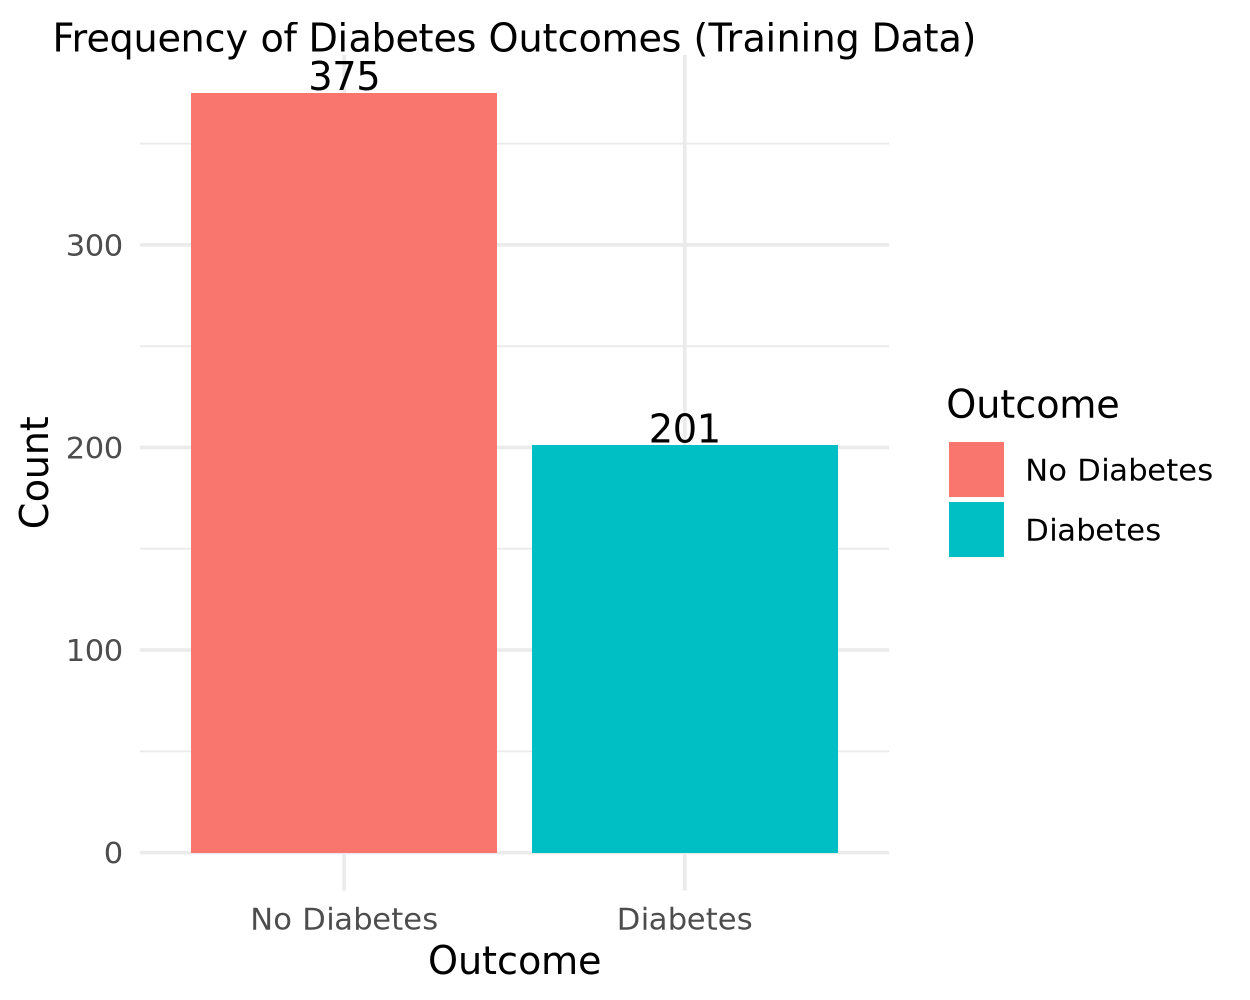

In [5]:
library(ggplot2)

#diabetes_train <- read.csv("diabetes.csv")  # had to reload file because diabetes_train wasn't acting as a dataframe, this caused some headaches...

diabetes = readr::read_csv('diabetes.csv', show_col_types = FALSE) |> mutate(Outcome = factor(Outcome))

split = initial_split(diabetes, strata = Outcome)

diabetes_train = training(split)

spec(diabetes_train)
#diabetes_test = testing(split)


# Convert Outcome to factor 
diabetes_train$Outcome <- factor(diabetes_train$Outcome,
                                 levels = c(0, 1),
                                 labels = c("No Diabetes", "Diabetes"))

ggplot(diabetes_train, aes(x = Outcome, fill = Outcome)) +
  geom_bar() +
  geom_text(stat = "count",           # added this in to see what the actual count is...
            aes(label = after_stat(count)),
            vjust = -0.1) +
  labs(
    title = "Frequency of Diabetes Outcomes (Training Data)",
    x = "Outcome",
    y = "Count"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(margin = margin(b = 30)) +
  theme(legend.position = "none")
)     


❓ Is the data balanced? I.e. do we have equal counts of each outcome?

##  No there are 375 "No Diabetes" counts as compared with 201 "Diabetes" counts according to the bar chart.  I added in a method to make an actual count of the cases. 

Run the code below to create a table for plotting the predictors we will use in our model: `Glucose` and `BMI`. 

In [6]:
plot_df = diabetes_train |>
    select(Outcome, Glucose, BMI) |>
    pivot_longer(cols = c(Glucose, BMI))

plot_df |> head()

Outcome,name,value
<fct>,<chr>,<dbl>
No Diabetes,Glucose,89.0
No Diabetes,BMI,28.1
No Diabetes,Glucose,116.0
No Diabetes,BMI,25.6
No Diabetes,Glucose,110.0
No Diabetes,BMI,37.6


Using `plot_df`, make a chart showing the relationship of `Glucose` and `BMI` with `Outcome`. 

- use `geom_jitter` for your "geom"
- `facet_wrap` your chart by the `name` variable. (e.g. `facet_wrap(~name, ncol = 2, scales = 'free_x')`)

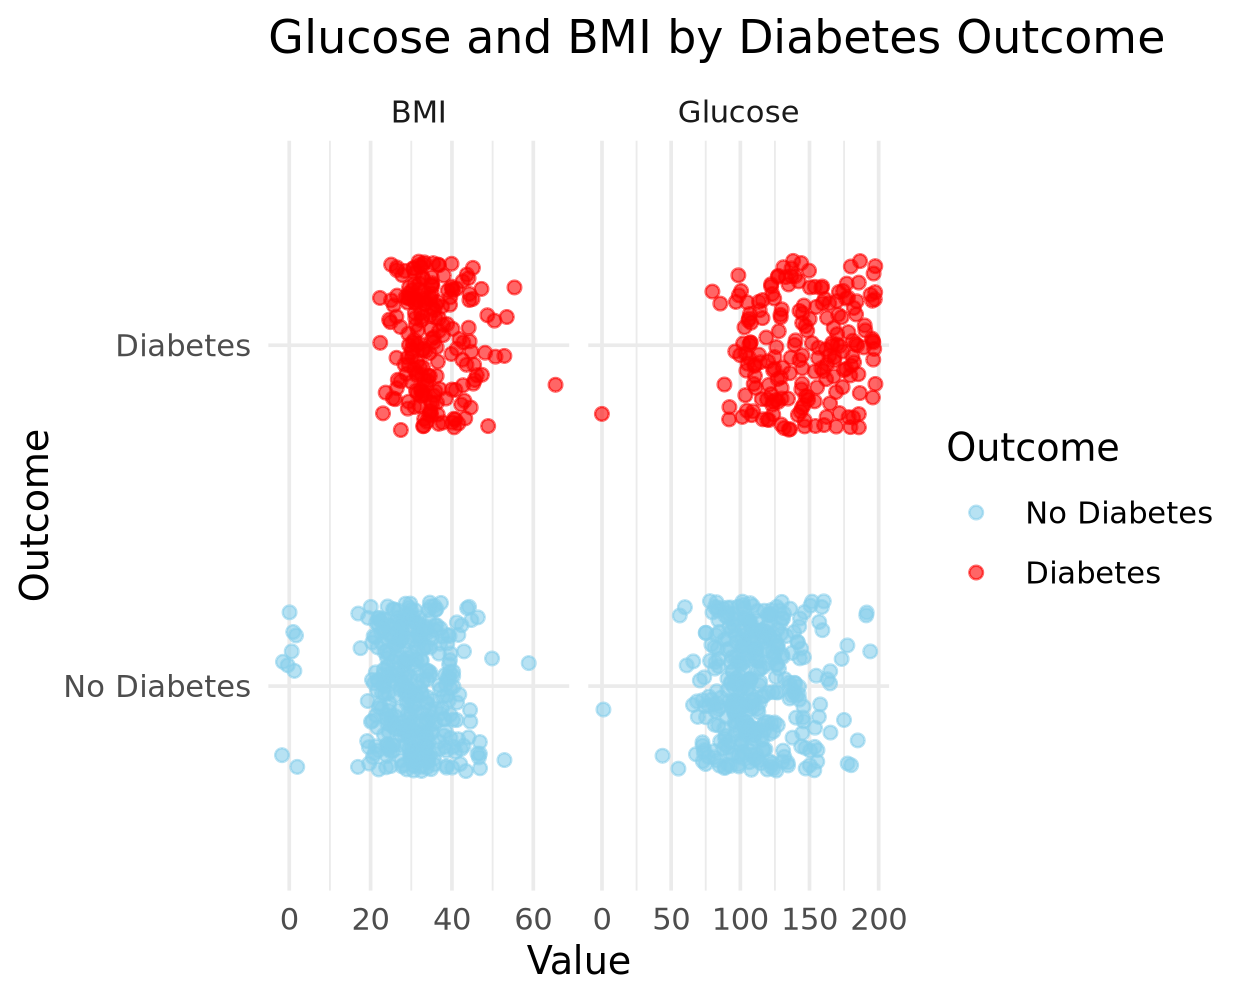

In [7]:
library(ggplot2)
library(dplyr)
library(tidyr)

diabetes = readr::read_csv('diabetes.csv', show_col_types = FALSE) |> mutate(Outcome = factor(Outcome))  # re-introducing the diabetes_train file

split = initial_split(diabetes, strata = Outcome)

diabetes_train = training(split)

plot_df <- diabetes_train |>
  select(Outcome, Glucose, BMI) |>
  pivot_longer(cols = c(Glucose, BMI))

# Convert Outcome INSIDE plot_df (this was hard to debug!! )
plot_df$Outcome <- factor(plot_df$Outcome,
                          levels = c(0, 1),
                          labels = c("No Diabetes", "Diabetes"))

ggplot(plot_df, aes(x = value, y = Outcome)) +
  geom_jitter(aes(color = Outcome), alpha = 0.6, width = 2, height = 0.25) +  # putting the color in geom_jitter finally corrected the bug
  scale_color_manual(values = c("skyblue", "red")) +
  facet_wrap(~name, ncol = 2, scales = "free_x") +
  labs(
    title = "Glucose and BMI by Diabetes Outcome",
    x = "Value",
    y = "Outcome",
    color = "Outcome"
  ) +
  theme_minimal()


❓ What happens when you remove the `scales = 'free_x'` argument from the `facet_wrap` function?

## When I removed the 'scales = 'free_x' argument, the resulting graph (below) has both x-axis scales being the same scale, or 0 - 200.  In the original plot (above) with 'scales = 'free_x' left in, the x-axis is shifted (a 0 - 60 scale) to give a better comparison of the comparison of BMI in the two outcomes.  

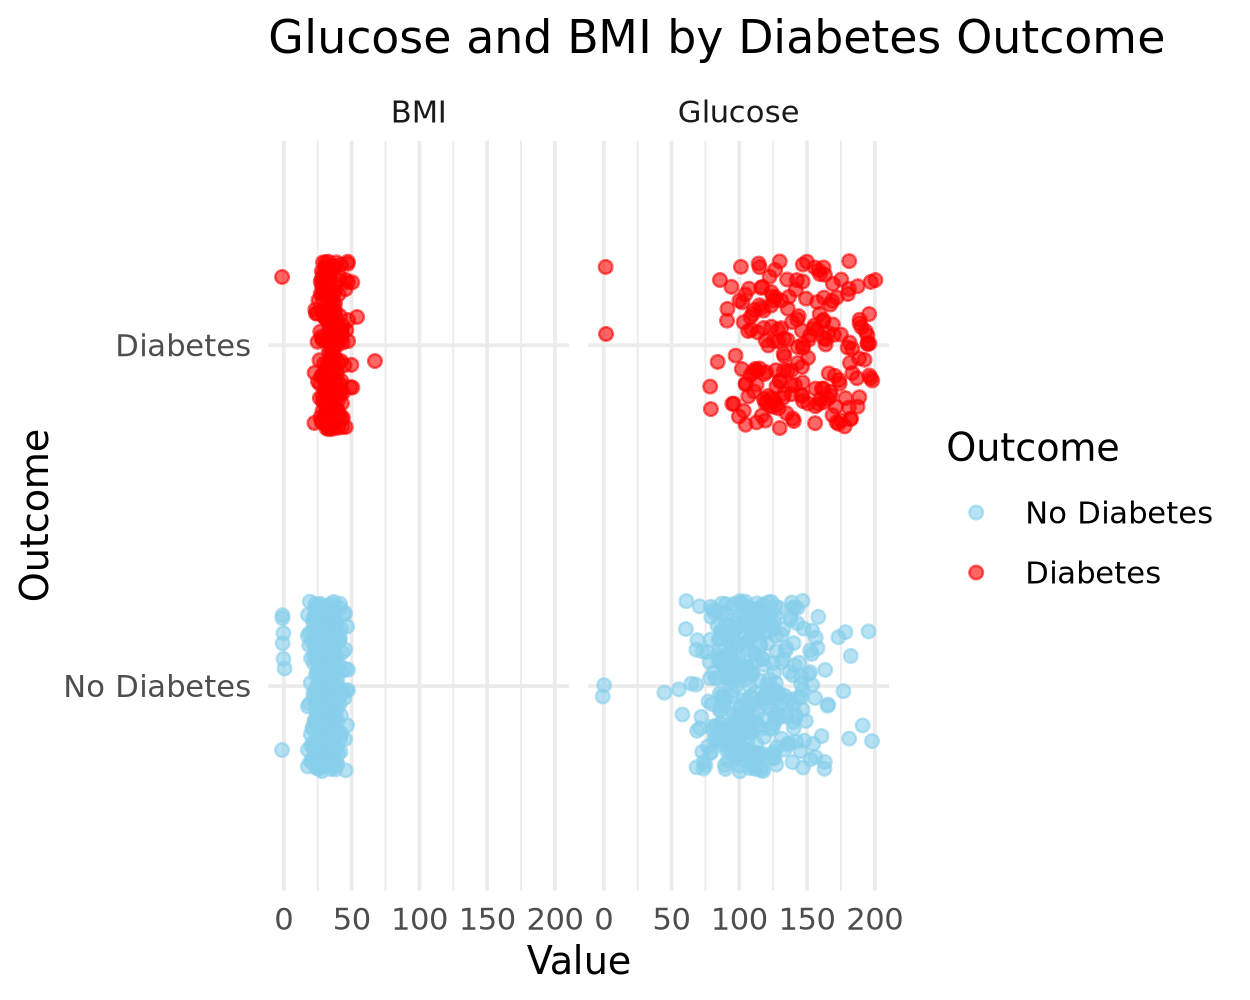

In [8]:
library(ggplot2)
library(dplyr)
library(tidyr)

diabetes = readr::read_csv('diabetes.csv', show_col_types = FALSE) |> mutate(Outcome = factor(Outcome))

split = initial_split(diabetes, strata = Outcome)

diabetes_train = training(split)

plot_df <- diabetes_train |>
  select(Outcome, Glucose, BMI) |>
  pivot_longer(cols = c(Glucose, BMI))

# Convert Outcome INSIDE plot_df (important)
plot_df$Outcome <- factor(plot_df$Outcome,
                          levels = c(0, 1),
                          labels = c("No Diabetes", "Diabetes"))

ggplot(plot_df, aes(x = value, y = Outcome)) +
  geom_jitter(aes(color = Outcome), alpha = 0.6, width = 2, height = 0.25) +
  scale_color_manual(values = c("skyblue", "red")) +
  facet_wrap(~name, ncol = 2) +
  labs(
    title = "Glucose and BMI by Diabetes Outcome",
    x = "Value",
    y = "Outcome",
    color = "Outcome"
  ) +
  theme_minimal()


Using your training data, build logistic regression model of `Outcome` with `BMI` and `Glucose` as predictors. 
- Use "glm" for you engine
- The formula for your fit function will be `Outcome ~ BMI + Glucose`

In [9]:
diabetes = readr::read_csv('diabetes.csv', show_col_types = FALSE) |> mutate(Outcome = factor(Outcome))

split = initial_split(diabetes, strata = Outcome)

diabetes_train = training(split)

model <- glm(Outcome ~ BMI + Glucose, # so using this method allows you to create a model without a recipe, prepping, or doing the other things
             data = diabetes_train, 
             family = binomial)

summary(model)

# using summary(model) gives the statistical analysis of the function; the significance codes show the predictors are statistaclly significant. 


Call:
glm(formula = Outcome ~ BMI + Glucose, family = binomial, data = diabetes_train)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -6.941472   0.664337 -10.449  < 2e-16 ***
BMI          0.069844   0.014775   4.727 2.28e-06 ***
Glucose      0.032482   0.003771   8.614  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 745.11  on 575  degrees of freedom
Residual deviance: 598.17  on 573  degrees of freedom
AIC: 604.17

Number of Fisher Scoring iterations: 4


Using `augment` with your fitted model and the `diabetes_test` data as arguments, create a new dataset called `diabetes_test_wPred` that is the `diabetes_test` table including predictions from your model. 

In [10]:
library(broom)

diabetes = readr::read_csv('diabetes.csv', show_col_types = FALSE) |> mutate(Outcome = factor(Outcome))
split = initial_split(diabetes, strata = Outcome)
diabetes_test = testing(split)  # putting this in here to make sure it can call diabetes_test

diabetes_test_wPred <- augment(model, newdata = diabetes_test)

glimpse(diabetes_test_wPred)



Rows: 192
Columns: 10
$ Pregnancies              <dbl> 0, 8, 10, 0, 8, 3, 9, 0, 1, 2, 5, 1, 2, 1, 1,…
$ Glucose                  <dbl> 137, 125, 168, 118, 99, 180, 171, 180, 146, 7…
$ BloodPressure            <dbl> 40, 96, 74, 84, 84, 64, 110, 66, 56, 70, 74, …
$ SkinThickness            <dbl> 35, 0, 0, 47, 0, 25, 24, 39, 0, 27, 27, 13, 2…
$ Insulin                  <dbl> 168, 0, 0, 230, 0, 70, 240, 0, 0, 0, 0, 38, 9…
$ BMI                      <dbl> 43.1, 0.0, 38.0, 45.8, 35.4, 34.0, 45.4, 42.0…
$ DiabetesPedigreeFunction <dbl> 2.288, 0.232, 0.537, 0.551, 0.388, 0.271, 0.7…
$ Age                      <dbl> 33, 54, 34, 31, 50, 26, 54, 25, 29, 22, 32, 2…
$ Outcome                  <fct> 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, …
$ .fitted                  <dbl> 0.51884307, -2.88120339, 1.16958713, 0.090260…


Run the code below to generate a confusion matrix for your model predictions. 

(❗️Hint: See Table 4.4 from [*Introduction to Statistical Learning (Version 2)*](https://www.statlearning.com/) for an example confusion matrix.)

In [11]:
library(broom)
library(dplyr)
library(yardstick)

diabetes = readr::read_csv('diabetes.csv', show_col_types = FALSE) |> mutate(Outcome = factor(Outcome))
split = initial_split(diabetes, strata = Outcome)
diabetes_test = testing(split)  # putting this in here to make sure it can call diabetes_test

diabetes_test_wPred <- augment(model, newdata = diabetes_test)


diabetes_test <- diabetes_test |>  # after playing with this for way too long I added this to label the column and row headers to make 
    mutate(                         # it easier to interpret the results of the table
        Outcome = factor(Outcome, 
                         levels = c(0,1),
                         labels = c("No Diabetes", "Diabetes"))
    )

diabetes_test_wPred <- augment(model, newdata = diabetes_test) |>
    mutate(
        prob = predict(model, newdata = diabetes_test, type = "response"),
        .pred_class = ifelse(prob >= 0.5, "Diabetes", "No Diabetes"),
        .pred_class = factor(.pred_class, levels = levels(Outcome))
    )

cm <- diabetes_test_wPred |>  # create a confusion matrix object to later create totals for rows and columns
    conf_mat(Outcome, .pred_class)
cm_with_totals <- as.matrix(cm$table)

# add row totals in
cm_with_totals <- cbind(cm_with_totals, Total = rowSums(cm_with_totals))

# add column totals in
cm_with_totals <- rbind(cm_with_totals, Total = colSums(cm_with_totals))

#convert to tibble
cm_with_totals <- as.data.frame(cm_with_totals) |>
    tibble::rownames_to_column("Actual") |>
    as_tibble()
cm_with_totals   # and this creates a row for the total in each column and a column for the totals in each row

#diabetes_test_wPred |> conf_mat(Outcome, .pred_class)

Actual,No Diabetes,Diabetes,Total
<chr>,<dbl>,<dbl>,<dbl>
No Diabetes,111,37,148
Diabetes,14,30,44
Total,125,67,192


❓ Based on the confusion matrix above, 
- How many individuals had diabetes in your test data?
- Of those that actually had diabetes, how many were predicted to have diabetes by your model?
- How many individuals predicted to have diabetes did not have diabetes?

## According to my confusion matrix above, the number of people who were predicted to have diabetes and who actually have diabetes is 30, while the total number of people with diabetes is 44.  The model predicts that the true positives (those who actually have diabetes and were predicted to have diabetes) is 30, while 14 were predicted to have diabetes but didn't (false negatives).  